# 03 — TCN: Temporal Convolutional Network

**Architecture:** Multi-task TCN — classifies direction (Up/Down) and regresses forward volatility.
**Label:** Triple Barrier Method (TBM) ±2σ, 24h vertical barrier.
**Splits:** Train ≤ 2022-12-31 · Grid-val 2023 · OOS 2024-01-01→latest (aligned with LGBM/Mamba).
**Device:** CUDA if available, else MPS, else CPU.

Loads `BTCUSDT_1h_unified.parquet`. Outputs standard artifacts for meta-learning.


In [1]:
import calendar, itertools, json, math, random, time, warnings
from pathlib import Path

import matplotlib as mpl
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import QuantileTransformer
from torch.optim import AdamW
from torch.optim.lr_scheduler import OneCycleLR
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.4f}'.format)
SEED=42; random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

try: plt.style.use('seaborn-v0_8-whitegrid')
except: plt.style.use('seaborn-whitegrid')
mpl.rcParams.update({
    'font.family':'serif','font.serif':['DejaVu Serif'],
    'axes.spines.top':False,'axes.spines.right':False,
    'axes.labelsize':10,'axes.titlesize':11,'xtick.labelsize':9,'ytick.labelsize':9,
    'legend.fontsize':9,'figure.dpi':120,'savefig.dpi':200,'savefig.bbox':'tight',
})
ACCENT='#F7931A'; BLUE='#2962FF'; GREY='#9E9E9E'; RED='#EF5350'; GREEN='#26A69A'

if torch.cuda.is_available():    DEVICE=torch.device('cuda')
elif torch.backends.mps.is_available() and torch.backends.mps.is_built(): DEVICE=torch.device('mps')
else: DEVICE=torch.device('cpu')

def _repo_root():
    p=Path.cwd()
    while p!=p.parent:
        if (p/'pyproject.toml').exists(): return p
        p=p.parent
    raise RuntimeError('pyproject.toml not found — run from inside the repo')

REPO     = _repo_root()
ARTS_DIR = REPO/'artifacts'/'notebooks_v2'/'03_tcn'
ARTS_DIR.mkdir(parents=True, exist_ok=True)
print(f'Device  : {DEVICE}')
print(f'Artifacts → {ARTS_DIR}')


Device  : mps
Artifacts → /Users/wojciech.neuman/Documents/hybrid-multi-agent-trading-system/artifacts/notebooks_v2/03_tcn


In [2]:
# ── Splits (aligned: OOS = 2-year unified window) ─────────────────────────────
TRAIN_END    = pd.Timestamp('2022-12-31')
GRID_VAL_END = pd.Timestamp('2024-05-30')   # grid-val ends just before OOS
OOS_START    = pd.Timestamp('2024-06-01')   # true OOS: 2 full years
OOS_END        = pd.Timestamp('2026-05-31')   # inclusive upper bound (data ends 2026-05-16)

TBM_VOL_WINDOW=24; TBM_MULT=2.0; TBM_VERT_H=24
FRAC_D=0.4; FFD_THRES=1e-4
SEQ_LEN=48
TCN_CHANNELS=[64,64,64,64]; TCN_KERNEL=3; TCN_DROPOUT=0.20
EPOCHS=80; WARMUP_EPOCHS=5; BATCH_SIZE=256; LR=3e-4; WEIGHT_DECAY=1e-4
PATIENCE=15; LAMBDA_VOL=0.50; AUX_FWD_H=6

MAKER_FEE=0.0000; SPOT_TAKER_FEE=0.0005; FUTURES_TAKER_FEE=0.0005
BUFFER=0.0005; SHORT_FUNDING_H=0.0000077; MIN_SL=0.010

LGBM_CORE=['stoch_k_14','ret_2h','rsi_divergence','close_vs_sma_7','bear_streak',
           'close_vs_s1','macd_hist_5_13','ad_z_48h','ret_3h']
V1_EXTRA=['ret_1h','rsi_14','vol_ratio_24h','bb_position_20','hour_sin','hour_cos',
          'atr_14_pct','hurst_168h','trend_score','close_vs_sma_50','ma_bull_score']
V4_FEATURES=['close_vs_true_vwap','hurst_24h','hurst_72h','tfi_pct','tfi_z_24h',
             'bb_width_pct','sideways_flag']
STRUCT_FEATURES=['liq_vwap_dev_24h','volat_atr_20_pct','mtf_alignment','mtf_h4_rsi']
BASE_FEATURES=LGBM_CORE+V1_EXTRA+V4_FEATURES+STRUCT_FEATURES

TRADING_GRID={
    # symmetric: long fires at p(up)>0.5+t, short fires at p(down)>0.5+t
    # prevents overtrading from sub-0.5 thresholds
    'signal_threshold':[0.08,0.10,0.13,0.15,0.18],
    'entry_atr_mult': [0.0,0.3,0.6],
    'sl_atr_mult':    [1.5,2.0,2.5],
    'tp_atr_mult':    [2.0,2.5,3.0],
    'min_hold':       [6,12],
    'max_hold':       [24,48],
    'cooldown':       [2,3],
}
_all_combos=list(itertools.product(*TRADING_GRID.values()))
_grid_keys=list(TRADING_GRID)
MIN_LONG_RATIO=0.10

rf=1+2*(TCN_KERNEL-1)*sum(2**i for i in range(len(TCN_CHANNELS)))
print(f'Device : {DEVICE}')
print(f'OOS    : {OOS_START.date()} → 2026-05-31 (2-year unified window)')
print(f'Grid-val ends: {GRID_VAL_END.date()}')
print(f'Artifacts → {ARTS_DIR}')

Device : mps
OOS    : 2024-06-01 → 2026-05-31 (2-year unified window)
Grid-val ends: 2024-05-30
Artifacts → /Users/wojciech.neuman/Documents/hybrid-multi-agent-trading-system/artifacts/notebooks_v2/03_tcn


## 1 · Load data

In [3]:

UNIFIED=REPO/'data'/'features'/'BTCUSDT_1h_unified.parquet'
if not UNIFIED.exists():
    raise FileNotFoundError(f'{UNIFIED} not found — run 00_data_ingestion_v1.ipynb first.')

df=pd.read_parquet(UNIFIED)
df.index=df.index.tz_localize(None) if df.index.tz else df.index

missing=[f for f in BASE_FEATURES if f not in df.columns]
if missing: print(f'WARNING — missing: {missing}')
else: print(f'All {len(BASE_FEATURES)} base features present.')
print(f'Shape: {df.shape}  ({df.index.min().date()} → {df.index.max().date()})')


All 31 base features present.
Shape: (74366, 292)  (2017-11-15 → 2026-05-16)


## 2 · Fractional differentiation

In [4]:

log_close=np.log(df['close'])

def _ffd_weights(d,thres=1e-4):
    w=[1.0]; k=1
    while True:
        w_k=-w[-1]*(d-k+1)/k; w.append(w_k)
        if abs(w_k)<thres: break
    return np.array(w[::-1])

def _ffd_series(series,d,thres=1e-4):
    w=_ffd_weights(d,thres); n_w=len(w); n=len(series)
    out=np.full(n,np.nan)
    for i in range(n_w-1,n):
        out[i]=float(np.dot(w,series.iloc[i-n_w+1:i+1].values))
    return pd.Series(out,index=series.index,name=f'ffd_{d}')

ffd_col='ffd_log_price'
df[ffd_col]=_ffd_series(log_close,FRAC_D,FFD_THRES)
print(f'FFD d={FRAC_D}: {df[ffd_col].notna().sum():,} valid bars  '
      f'(first valid: {df[ffd_col].dropna().index[0].date()})')


FFD d=0.4: 74,355 valid bars  (first valid: 2017-11-15)


## 3 · TBM labels

In [5]:

log_rets=log_close.diff()
rolling_vol=log_rets.rolling(TBM_VOL_WINDOW).std()
close_vals=df['close'].values; vol_vals=rolling_vol.values; n=len(df)

y_dir=np.full(n,np.nan,dtype=np.float32)
y_fwd_vol=np.full(n,np.nan,dtype=np.float32)
t0_=time.time()
for i in range(n):
    if np.isnan(vol_vals[i]) or vol_vals[i]==0: continue
    sigma=vol_vals[i]*close_vals[i]
    up=close_vals[i]+TBM_MULT*sigma; dn=close_vals[i]-TBM_MULT*sigma
    end_j=min(i+TBM_VERT_H,n)
    for j in range(i+1,end_j):
        if close_vals[j]>=up:   y_dir[i]=1; break
        if close_vals[j]<=dn:   y_dir[i]=0; break
    else: y_dir[i]=-1  # -1 = vertical timeout
    fwd=log_rets.iloc[i+1:i+1+AUX_FWD_H].values
    if len(fwd): y_fwd_vol[i]=float(np.std(fwd))

df['y_dir']    =y_dir
df['y_fwd_vol']=y_fwd_vol
valid_dir=np.array([v in (0,1) for v in y_dir])
print(f'TBM done in {time.time()-t0_:.0f}s  |  Up={int((y_dir==1).sum()):,}  '
      f'Down={int((y_dir==0).sum()):,}  Timeout={int((y_dir==-1).sum()):,}  '
      f'NaN={int(np.isnan(y_dir).sum()):,}')


TBM done in 1s  |  Up=33,433  Down=32,130  Timeout=8,779  NaN=24


## 4 · Splits & feature assembly

In [6]:

ALL_FEATURES=BASE_FEATURES+[ffd_col]

train_mask=(df.index<=TRAIN_END)&valid_dir&df[ALL_FEATURES].notna().all(axis=1)
val_mask  =(df.index>TRAIN_END)&(df.index<=GRID_VAL_END)&valid_dir&df[ALL_FEATURES].notna().all(axis=1)
oos_mask  =(df.index>=OOS_START)&df[ALL_FEATURES].notna().all(axis=1)

df_tr =df[train_mask].copy(); df_vl=df[val_mask].copy(); df_oos=df[oos_mask].copy()
print(f'Train  : {len(df_tr):,}  ({df_tr.index.min().date()} → {df_tr.index.max().date()})')
print(f'Val    : {len(df_vl):,}  ({df_vl.index.min().date()} → {df_vl.index.max().date()})')
print(f'OOS    : {len(df_oos):,}  ({OOS_START.date()} → {df_oos.index[-1].date()})')


Train  : 39,658  (2017-11-16 → 2022-12-30)
Val    : 10,612  (2022-12-31 → 2024-05-30)
OOS    : 17,137  (2024-06-01 → 2026-05-16)


## 5 · Normalisation & sequence building

In [7]:

qt=QuantileTransformer(output_distribution='normal',n_quantiles=1000,random_state=SEED)
X_tr_raw=np.nan_to_num(df_tr[ALL_FEATURES].values.astype(np.float32))
X_vl_raw=np.nan_to_num(df_vl[ALL_FEATURES].values.astype(np.float32))
X_oos_raw=np.nan_to_num(df_oos[ALL_FEATURES].values.astype(np.float32))
X_tr =qt.fit_transform(X_tr_raw).astype(np.float32)
X_vl =qt.transform(X_vl_raw).astype(np.float32)
X_oos=qt.transform(X_oos_raw).astype(np.float32)

def make_seqs(X,y_d,y_v,seq_len):
    ends=[]; Xs=[]; Yd=[]; Yv=[]
    for i in range(seq_len-1,len(X)):
        yd=y_d[i]; yv=y_v[i]
        if yd not in (0,1): continue
        Xs.append(X[i-seq_len+1:i+1]); Yd.append(int(yd)); Yv.append(yv if not np.isnan(yv) else 0.0)
    return (np.stack(Xs).astype(np.float32),np.array(Yd,dtype=np.int64),
            np.array(Yv,dtype=np.float32))

X_tr_s,y_tr_d,y_tr_v=make_seqs(X_tr,df_tr['y_dir'].values,df_tr['y_fwd_vol'].values,SEQ_LEN)
X_vl_s,y_vl_d,y_vl_v=make_seqs(X_vl,df_vl['y_dir'].values,df_vl['y_fwd_vol'].values,SEQ_LEN)
print(f'Train seqs: {len(X_tr_s):,}  Val seqs: {len(X_vl_s):,}')
print(f'Train label balance: {np.bincount(y_tr_d)}  Val: {np.bincount(y_vl_d)}')
N_FEATURES=X_tr_s.shape[2]


Train seqs: 39,611  Val seqs: 10,565
Train label balance: [19601 20010]  Val: [4970 5595]


## 6 · TCN model

In [8]:

class CausalBlock(nn.Module):
    def __init__(self,in_c,out_c,kernel,dilation,dropout):
        super().__init__()
        pad=(kernel-1)*dilation
        self.conv1=nn.Conv1d(in_c,out_c,kernel,dilation=dilation,padding=pad)
        self.conv2=nn.Conv1d(out_c,out_c,kernel,dilation=dilation,padding=pad)
        self.skip =nn.Conv1d(in_c,out_c,1) if in_c!=out_c else None
        self.drop =nn.Dropout(dropout); self.pad=pad
        self.norm1=nn.LayerNorm(out_c); self.norm2=nn.LayerNorm(out_c)
    def forward(self,x):
        r=x
        y=F.relu(self.norm1(self.conv1(x)[...,:x.shape[-1]].transpose(1,2)).transpose(1,2))
        y=self.drop(y)
        y=F.relu(self.norm2(self.conv2(y)[...,:x.shape[-1]].transpose(1,2)).transpose(1,2))
        y=self.drop(y)
        if self.skip: r=self.skip(r)
        return F.relu(y+r)

class TCNMultiTask(nn.Module):
    def __init__(self,n_feat,channels,kernel,dropout,n_classes=2):
        super().__init__()
        layers=[]; in_c=n_feat
        for i,out_c in enumerate(channels):
            layers.append(CausalBlock(in_c,out_c,kernel,2**i,dropout)); in_c=out_c
        self.tcn=nn.Sequential(*layers)
        self.cls_head=nn.Linear(channels[-1],n_classes)
        self.vol_head=nn.Linear(channels[-1],1)
    def forward(self,x):
        # x: (B, T, F) → transpose → (B, F, T)
        h=self.tcn(x.transpose(1,2))  # (B, C, T)
        last=h[:,:,-1]                 # (B, C)
        return self.cls_head(last), self.vol_head(last).squeeze(-1)

model=TCNMultiTask(N_FEATURES,TCN_CHANNELS,TCN_KERNEL,TCN_DROPOUT).to(DEVICE)
n_params=sum(p.numel() for p in model.parameters())
print(f'TCNMultiTask: {n_params:,} params  |  in_features={N_FEATURES}')


TCNMultiTask: 96,003 params  |  in_features=32


## 7 · Training

In [9]:

# Class weights for direction head
counts=np.bincount(y_tr_d,minlength=2)
w=torch.tensor(1.0/counts,dtype=torch.float32).to(DEVICE); w/=w.sum()
cls_crit=nn.CrossEntropyLoss(weight=w)
vol_crit=nn.MSELoss()

train_ds=TensorDataset(torch.from_numpy(X_tr_s),torch.from_numpy(y_tr_d),torch.from_numpy(y_tr_v))
val_ds  =TensorDataset(torch.from_numpy(X_vl_s),torch.from_numpy(y_vl_d),torch.from_numpy(y_vl_v))
ld_tr=DataLoader(train_ds,BATCH_SIZE,shuffle=True,drop_last=True)
ld_vl=DataLoader(val_ds, BATCH_SIZE,shuffle=False)

opt=torch.optim.AdamW(model.parameters(),lr=LR,weight_decay=WEIGHT_DECAY)
from torch.optim.lr_scheduler import OneCycleLR
sched=OneCycleLR(opt,max_lr=LR,epochs=EPOCHS,steps_per_epoch=len(ld_tr))

hist={'tl':[],'vl':[],'va':[]}; best_vl=1e9; best_state=None; best_epoch=0
t_run=time.time()
for ep in range(1,EPOCHS+1):
    model.train(); tl=0.
    for xb,yd,yv in ld_tr:
        xb=xb.to(DEVICE); yd=yd.to(DEVICE); yv=yv.to(DEVICE)
        opt.zero_grad()
        logits,vol_pred=model(xb)
        loss=cls_crit(logits,yd)+LAMBDA_VOL*vol_crit(vol_pred,yv)
        loss.backward(); nn.utils.clip_grad_norm_(model.parameters(),1.0); opt.step(); sched.step()
        tl+=loss.item()
    tl/=len(ld_tr)
    model.eval(); vl=0.; ps=[]; ys=[]
    with torch.no_grad():
        for xb,yd,yv in ld_vl:
            xb=xb.to(DEVICE); yd=yd.to(DEVICE); yv=yv.to(DEVICE)
            logits,vol_pred=model(xb)
            vl+=(cls_crit(logits,yd)+LAMBDA_VOL*vol_crit(vol_pred,yv)).item()
            ps.append(torch.softmax(logits,-1)[:,1].cpu().numpy()); ys.append(yd.cpu().numpy())
    vl/=len(ld_vl); va=roc_auc_score(np.concatenate(ys),np.concatenate(ps))
    hist['tl'].append(tl); hist['vl'].append(vl); hist['va'].append(va)
    if vl<best_vl:
        best_vl=vl; best_epoch=ep
        best_state={k:v.cpu().clone() for k,v in model.state_dict().items()}
        torch.save(best_state, ARTS_DIR/'model.pt')
    if ep%5==0 or ep==1:
        print(f'Ep {ep:>3}  train_loss={tl:.4f}  val_loss={vl:.4f}  val_auc={va:.4f}  '
              f'best_ep={best_epoch}')
    if ep-best_epoch>=PATIENCE: print(f'Early stop @ ep {ep}'); break
print(f'Done in {(time.time()-t_run)/60:.1f} min  |  best_epoch={best_epoch}  best_val_loss={best_vl:.5f}')
model.load_state_dict(best_state)


Ep   1  train_loss=1.2045  val_loss=0.7987  val_auc=0.5011  best_ep=1


Ep   5  train_loss=0.7544  val_loss=0.7160  val_auc=0.5119  best_ep=5


Ep  10  train_loss=0.7007  val_loss=0.6996  val_auc=0.5205  best_ep=9


Ep  15  train_loss=0.6843  val_loss=0.6952  val_auc=0.5241  best_ep=14


Ep  20  train_loss=0.6624  val_loss=0.7040  val_auc=0.5234  best_ep=14


Ep  25  train_loss=0.6181  val_loss=0.7444  val_auc=0.5273  best_ep=14


Early stop @ ep 29
Done in 0.8 min  |  best_epoch=14  best_val_loss=0.69312


<All keys matched successfully>

## 8 · OOS inference

In [10]:

# OOS: infer on all bars >= OOS_START
# We need a rolling window of SEQ_LEN bars preceding each OOS bar
# Include last SEQ_LEN-1 bars of pre-OOS data so the first OOS bar has full context
pre_oos_start = df_oos.index[0] - pd.Timedelta(hours=SEQ_LEN-1)
pre_oos_df = df[df.index >= pre_oos_start].copy()
X_pre = qt.transform(np.nan_to_num(pre_oos_df[ALL_FEATURES].values.astype(np.float32)))

model.eval(); oos_pup=[]; oos_pdown=[]
with torch.no_grad():
    for i in range(SEQ_LEN-1, len(X_pre)):
        xb=torch.from_numpy(X_pre[i-SEQ_LEN+1:i+1][None]).to(DEVICE)
        logits,_=model(xb)
        p=torch.softmax(logits,-1).cpu().numpy()[0]
        oos_pup.append(p[1]); oos_pdown.append(p[0])

oos_pup   =np.array(oos_pup,  dtype=np.float32)
oos_pdown =np.array(oos_pdown,dtype=np.float32)
oos_idx   =pre_oos_df.index[SEQ_LEN-1:]
assert len(oos_pup)==len(oos_idx)

# Trim to OOS window
trim=oos_idx>=OOS_START
oos_probs_arr  =oos_pup[trim]
oos_idx_arr    =oos_idx[trim]
oos_plot_df    =df_oos.copy()

auc_oos=roc_auc_score(
    (df.loc[oos_idx_arr,'y_dir'].values==1).astype(int),
    oos_probs_arr
) if (df.loc[oos_idx_arr,'y_dir'].isin([0,1])).sum()>0 else float('nan')
print(f'OOS bars: {len(oos_probs_arr):,}  |  OOS AUC (TBM): {auc_oos:.4f}')


OOS bars: 17,137  |  OOS AUC (TBM): 0.5130


## 9 · Grid search on 2023 validation window

In [11]:
def _run_backtest(probs_arr, pdown_arr, close_arr, high_arr, low_arr, atr_arr,
        long_threshold, short_threshold, entry_atr_mult, sl_atr_mult, tp_atr_mult,
        min_hold, max_hold, cooldown, with_fees=True):
    n=len(close_arr); eq=np.ones(n); cur=1.0; trades=[]
    in_pos=False; direction=None; entry_px=sl_px=tp_px=pos_eq=entry_fee=0.0
    hold_cnt=cd_cnt=0; funding=0.0; pending=None
    for i in range(n):
        lo=low_arr[i]; hi=high_arr[i]; px=close_arr[i]
        if in_pos:
            hold_cnt+=1
            if direction=='short': funding+=SHORT_FUNDING_H
            eq[i]=pos_eq*(px/entry_px if direction=='long' else 1+(entry_px-px)/entry_px)
            exited=False; exit_px=0.; reason=''; exit_fee=0.
            if hold_cnt>=min_hold:
                if direction=='long':
                    if lo<=sl_px: exit_px=sl_px;exited=True;reason='sl';exit_fee=SPOT_TAKER_FEE if with_fees else 0.
                    elif hi>=tp_px: exit_px=tp_px;exited=True;reason='tp';exit_fee=MAKER_FEE
                    elif hold_cnt>=max_hold: exit_px=px;exited=True;reason='timeout';exit_fee=SPOT_TAKER_FEE if with_fees else 0.
                else:
                    if hi>=sl_px: exit_px=sl_px;exited=True;reason='sl';exit_fee=FUTURES_TAKER_FEE if with_fees else 0.
                    elif lo<=tp_px: exit_px=tp_px;exited=True;reason='tp';exit_fee=MAKER_FEE
                    elif hold_cnt>=max_hold: exit_px=px;exited=True;reason='timeout';exit_fee=FUTURES_TAKER_FEE if with_fees else 0.
            if exited:
                gross=((exit_px-entry_px)/entry_px if direction=='long' else (entry_px-exit_px)/entry_px)
                net=gross-(entry_fee+exit_fee if with_fees else 0.)+funding
                cur=pos_eq*(1.+net); eq[i]=cur
                trades.append({'direction':direction,'reason':reason,'gross':gross,'net':net,'hold':hold_cnt})
                in_pos=False; cd_cnt=cooldown; funding=0.
        elif pending is not None:
            d,lim,p_sl,p_tp=pending
            if d=='long': filled=lo<=lim+BUFFER; ef=MAKER_FEE if (filled and with_fees) else (SPOT_TAKER_FEE if with_fees else 0.)
            else: filled=hi>=lim-BUFFER; ef=MAKER_FEE if (filled and with_fees) else (FUTURES_TAKER_FEE if with_fees else 0.)
            entry_px=lim if filled else px; sl_px=p_sl; tp_px=p_tp; entry_fee=ef
            direction=d; in_pos=True; pos_eq=cur; hold_cnt=0; funding=0.; pending=None; eq[i]=cur
        elif cd_cnt>0: cd_cnt-=1; eq[i]=cur
        elif i+1<n:
            atr=max(atr_arr[i],MIN_SL)
            if probs_arr[i]>long_threshold:
                pending=('long',px*(1-entry_atr_mult*atr),px*(1-sl_atr_mult*atr),px*(1+tp_atr_mult*atr))
            elif pdown_arr[i]>short_threshold:
                pending=('short',px*(1+entry_atr_mult*atr),px*(1+sl_atr_mult*atr),px*(1-tp_atr_mult*atr))
            eq[i]=cur
        else: eq[i]=cur
    if in_pos:
        gross=((px-entry_px)/entry_px if direction=='long' else (entry_px-px)/entry_px)
        taker=SPOT_TAKER_FEE if direction=='long' else FUTURES_TAKER_FEE
        net=gross-(entry_fee+(taker if with_fees else 0.))+funding; cur=pos_eq*(1.+net); eq[-1]=cur
    return eq, trades

def _sharpe(eq):
    r=np.diff(np.log(np.maximum(eq,1e-12))); return float(r.mean()/(r.std(ddof=1)+1e-12)*np.sqrt(24*365))
def _maxdd(eq):
    pk=np.maximum.accumulate(eq); return float(((eq-pk)/(pk+1e-12)).min())

# ── Regime definitions (unified across all notebooks_v2) ─────────────────────
REGIME_CHOP = (pd.Timestamp('2024-06-01'), pd.Timestamp('2024-11-05'))
REGIME_BULL = (pd.Timestamp('2024-11-06'), pd.Timestamp('2025-10-31'))
REGIME_BEAR = (pd.Timestamp('2025-11-01'), pd.Timestamp('2026-05-31'))
REGIME_COLOURS = {'Chop':'#9E9E9E','Bull':'#26A69A','Bear':'#EF5350'}
REGIME_ALPHA   = 0.10

def _sortino(eq):
    r   = np.diff(np.log(np.maximum(eq, 1e-12)))
    neg = r[r < 0]
    d   = neg.std(ddof=1) if len(neg)>1 else 1e-12
    return float(r.mean()/(d+1e-12)*np.sqrt(24*365))

def _regime_table(eq_arr, idx, close_arr):
    eq_s = pd.Series(eq_arr, index=idx)
    cl_s = pd.Series(close_arr, index=idx)
    rows = []
    for label,(s,e) in [('Full OOS',(idx.min(),idx.max())),
                         ('Regime 1 — Chop',REGIME_CHOP),
                         ('Regime 2 — Bull',REGIME_BULL),
                         ('Regime 3 — Bear',REGIME_BEAR)]:
        m = (idx>=s)&(idx<=e)
        if m.sum()<24: continue
        seg = eq_s[m].values/eq_s[m].values[0]
        bh  = cl_s[m].values/cl_s[m].values[0]
        pk  = np.maximum.accumulate(seg)
        dd  = float(((seg-pk)/(pk+1e-12)).min())
        rows.append({'Period':label,'Bars':int(m.sum()),
                     'Return':f'{seg[-1]-1:+.1%}','Sharpe':f'{_sharpe(seg):.3f}',
                     'Sortino':f'{_sortino(seg):.3f}','MaxDD':f'{dd:.1%}',
                     'BH_Ret':f'{bh[-1]-1:+.1%}','Alpha':f'{seg[-1]-bh[-1]:+.1%}'})
    return pd.DataFrame(rows).set_index('Period')

print('Backtest engine + regime analysis ready.')
# ── Val-window inference for grid search ─────────────────────────
val_oos_start=TRAIN_END+pd.Timedelta(hours=SEQ_LEN)
pre_val_df=df[(df.index>=val_oos_start-pd.Timedelta(hours=SEQ_LEN))&(df.index<=GRID_VAL_END)].copy()
Xv_=qt.transform(np.nan_to_num(pre_val_df[ALL_FEATURES].values.astype(np.float32)))
model.eval(); vp=[]; vd_=[]
with torch.no_grad():
    for i in range(SEQ_LEN-1,len(Xv_)):
        xb=torch.from_numpy(Xv_[i-SEQ_LEN+1:i+1][None]).to(DEVICE)
        logits,_=model(xb); p=torch.softmax(logits,-1).cpu().numpy()[0]
        vp.append(p); vd_.append(pre_val_df.index[i])
vp=np.array(vp,dtype=np.float32)
vp_up=vp[:,1]; vp_dn=vp[:,0]
val_df_bt=df.loc[vd_].copy()

MAX_TRADES_GRID = 350  # ~140/yr over 2.5yr grid-val; prevents overtrading overfits
rows=[]; t0=time.time()
for vals in _all_combos:
    p=dict(zip(_grid_keys,vals))
    if p['max_hold']<p['min_hold']: continue
    # expand symmetric threshold
    p_bt={**p,'long_threshold':0.5+p['signal_threshold'],'short_threshold':0.5+p['signal_threshold']}
    del p_bt['signal_threshold']
    eq,tr=_run_backtest(vp_up,vp_dn,val_df_bt['close'].values,val_df_bt['high'].values,
                        val_df_bt['low'].values,val_df_bt['atr_14_pct'].values,with_fees=True,**p_bt)
    if len(tr)<15 or len(tr)>MAX_TRADES_GRID: continue
    nl=sum(1 for t in tr if t['direction']=='long')
    rows.append({**p_bt,'signal_threshold':p['signal_threshold'],'sharpe':_sharpe(eq),'total_ret':float(eq[-1]-1),
                 'maxdd':_maxdd(eq),'win_rate':float(np.mean([t['net']>0 for t in tr])),'n_trades':len(tr),'n_long':nl})
grid_df=pd.DataFrame(rows).sort_values('sharpe',ascending=False).reset_index(drop=True)
INT={'min_hold','max_hold','cooldown'}
BEST={k:(int(grid_df.iloc[0][k]) if k in INT else float(grid_df.iloc[0][k])) for k in ['long_threshold','short_threshold','entry_atr_mult','sl_atr_mult','tp_atr_mult','min_hold','max_hold','cooldown']}
print(f'Grid done in {time.time()-t0:.0f}s  |  {len(grid_df):,} valid combos')
print('Best params:'); [print(f'  {k:<18}{v}') for k,v in BEST.items()]


Backtest engine + regime analysis ready.


Grid done in 4s  |  966 valid combos
Best params:
  long_threshold    0.63
  short_threshold   0.63
  entry_atr_mult    0.0
  sl_atr_mult       1.5
  tp_atr_mult       2.5
  min_hold          6
  max_hold          48
  cooldown          3


[None, None, None, None, None, None, None, None]

## 10 · OOS backtest & figures

                       Trades     Win   Return  Sharpe   MaxDD
--------------------------------------------------------------
With fees                 272   45.2%   +73.8%   1.141  -13.6%
Zero-fee                  272   45.2%   +90.4%   1.333  -12.2%


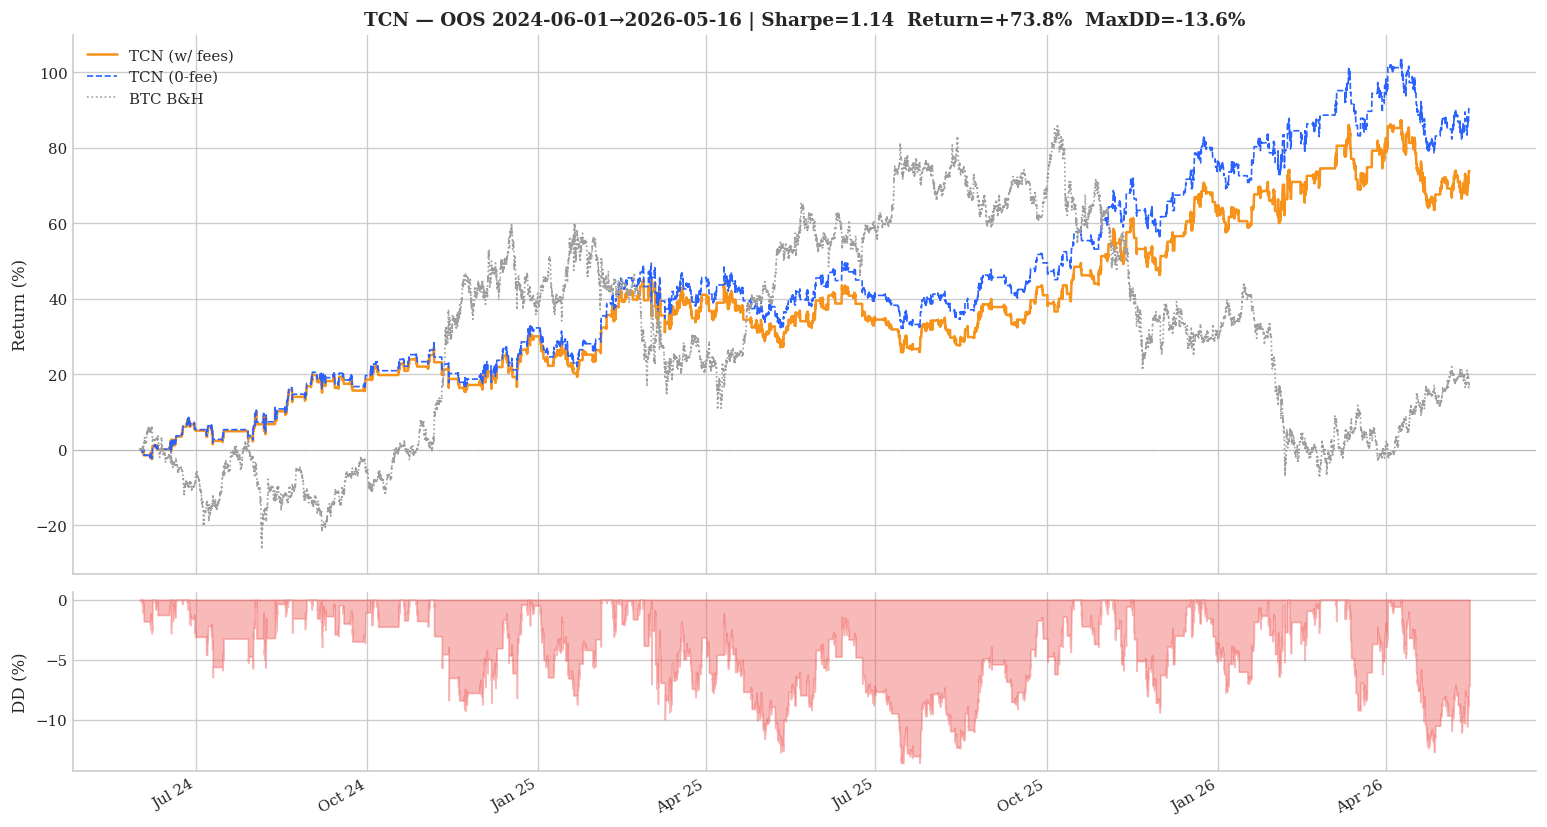

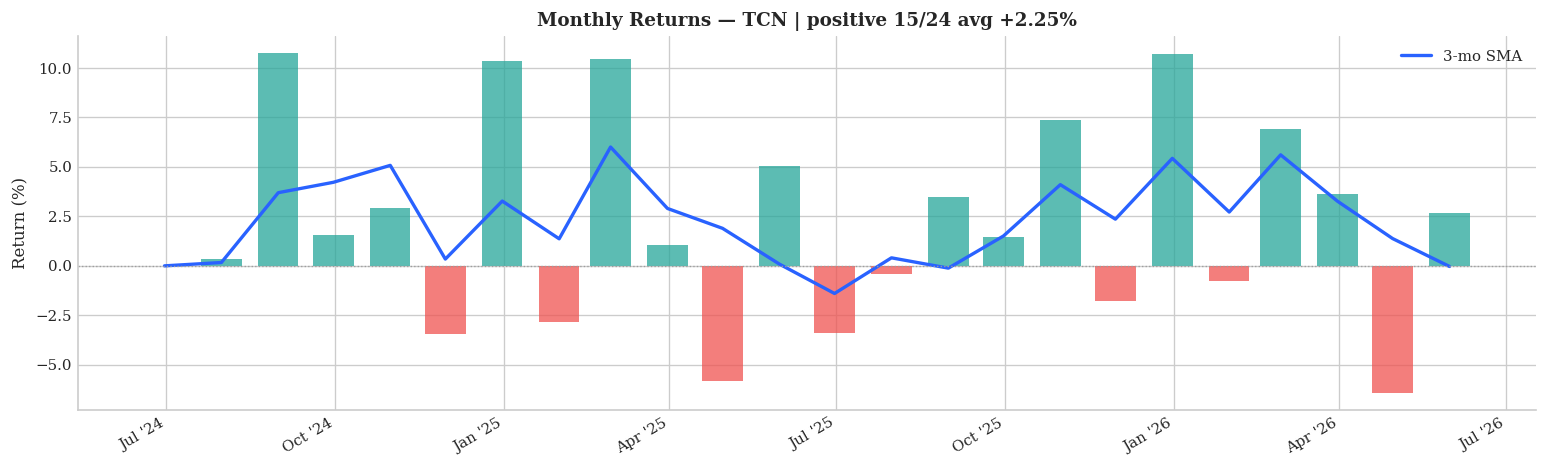

In [12]:

# Need pdown array for OOS too
model.eval(); oos_full=[]; oos_full_idx=[]
with torch.no_grad():
    for i in range(SEQ_LEN-1, len(X_pre)):
        xb=torch.from_numpy(X_pre[i-SEQ_LEN+1:i+1][None]).to(DEVICE)
        logits,_=model(xb); p=torch.softmax(logits,-1).cpu().numpy()[0]
        oos_full.append(p); oos_full_idx.append(pre_oos_df.index[i])
oos_full=np.array(oos_full,dtype=np.float32)
trim2=np.array(oos_full_idx)>=OOS_START
oos_pup2=oos_full[trim2,1]; oos_pdn2=oos_full[trim2,0]
oos_idx2=np.array(oos_full_idx)[trim2]
oos_plot_df=df.loc[oos_idx2].copy()
bh=(oos_plot_df['close'].values/oos_plot_df['close'].iloc[0]-1)*100

eq_fees,tdf_fees=_run_backtest(oos_pup2,oos_pdn2,oos_plot_df['close'].values,
    oos_plot_df['high'].values,oos_plot_df['low'].values,oos_plot_df['atr_14_pct'].values,with_fees=True,**BEST)
eq_0fee,tdf_0fee=_run_backtest(oos_pup2,oos_pdn2,oos_plot_df['close'].values,
    oos_plot_df['high'].values,oos_plot_df['low'].values,oos_plot_df['atr_14_pct'].values,with_fees=False,**BEST)
TF=pd.DataFrame(tdf_fees) if tdf_fees else pd.DataFrame(columns=['direction','reason','gross','net','hold'])
T0=pd.DataFrame(tdf_0fee) if tdf_0fee else pd.DataFrame(columns=['direction','reason','gross','net','hold'])

o_idx=pd.DatetimeIndex(oos_idx2)
print(f'{"":22}{"Trades":>7}{"Win":>8}{"Return":>9}{"Sharpe":>8}{"MaxDD":>8}')
print('-'*62)
for lbl,eq,t in [('With fees',eq_fees,TF),('Zero-fee',eq_0fee,T0)]:
    wr=(t['net']>0).mean() if len(t) else 0
    print(f'{lbl:22}{len(t):>7}{wr:>8.1%}{eq[-1]-1:>+9.1%}{_sharpe(eq):>8.3f}{_maxdd(eq):>8.1%}')

fig,(ax1,ax2)=plt.subplots(2,1,figsize=(13,7),height_ratios=[3,1],sharex=True)
ax1.plot(o_idx,(eq_fees-1)*100,color=ACCENT,lw=1.5,label='TCN (w/ fees)')
ax1.plot(o_idx,(eq_0fee-1)*100,color=BLUE,lw=1.0,ls='--',label='TCN (0-fee)')
ax1.plot(o_idx,bh,color=GREY,lw=1.0,ls=':',label='BTC B&H')
ax1.axhline(0,color=GREY,lw=0.6,ls=':'); ax1.set_ylabel('Return (%)'); ax1.legend()
ax1.set_title(f'TCN — OOS {OOS_START.date()}→{o_idx[-1].date()} | '
    f'Sharpe={_sharpe(eq_fees):.2f}  Return={eq_fees[-1]-1:+.1%}  MaxDD={_maxdd(eq_fees):.1%}',
    fontweight='bold')
pk=np.maximum.accumulate(eq_fees); dd=(eq_fees-pk)/pk*100
ax2.fill_between(o_idx,dd,0,color=RED,alpha=0.4); ax2.set_ylabel('DD (%)')
ax2.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1,4,7,10]))
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %y'))
plt.setp(ax2.xaxis.get_majorticklabels(),rotation=30,ha='right')
fig.tight_layout(); fig.savefig(ARTS_DIR/'01_equity_drawdown.png'); plt.show()

eqs=pd.Series(eq_fees,index=o_idx); mret=eqs.resample('ME').last().pct_change().fillna(0)*100
fig,ax=plt.subplots(figsize=(13,4))
ax.bar(mret.index,mret.values,color=[GREEN if r>=0 else RED for r in mret],width=22,alpha=0.75)
ax.plot(mret.index,mret.rolling(3,min_periods=1).mean(),color=BLUE,lw=2,label='3-mo SMA')
ax.axhline(0,color=GREY,lw=0.8,ls=':'); ax.set_ylabel('Return (%)'); ax.legend()
ax.set_title(f'Monthly Returns — TCN | positive {int((mret>0).sum())}/{len(mret)} avg {mret.mean():+.2f}%',fontweight='bold')
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1,4,7,10]))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b '%y"))
plt.setp(ax.xaxis.get_majorticklabels(),rotation=30,ha='right')
fig.tight_layout(); fig.savefig(ARTS_DIR/'02_monthly_returns.png'); plt.show()


## 11 · Save artifacts

In [13]:

np.save(ARTS_DIR/'oos_probs.npy', oos_pup2.astype(np.float32))
np.save(ARTS_DIR/'oos_index.npy',
        pd.DatetimeIndex(oos_idx2).astype('datetime64[ns]').astype(np.int64).values)

def _bt_metrics(eq,t):
    wr=float((t['net']>0).mean()) if len(t) else 0.
    nl=int((t['direction']=='long').sum()) if len(t) else 0
    ns=int((t['direction']=='short').sum()) if len(t) else 0
    return {'n_trades':len(t),'n_long':nl,'n_short':ns,'win_rate':round(wr,4),
            'total_ret':round(float(eq[-1]-1),4),'sharpe':round(_sharpe(eq),4),'maxdd':round(_maxdd(eq),4)}

results={
    'notebook':'03_tcn_v1','created':pd.Timestamp.now().isoformat(),
    'model':'TCNMultiTask (direction + forward-vol)',
    'splits':{'train_end':str(TRAIN_END.date()),'grid_val_end':str(GRID_VAL_END.date()),
              'oos_start':str(OOS_START.date())},
    'tbm':{'mult':TBM_MULT,'vol_window':TBM_VOL_WINDOW,'vert_h':TBM_VERT_H},
    'architecture':{'channels':TCN_CHANNELS,'kernel':TCN_KERNEL,'dropout':TCN_DROPOUT,
                    'seq_len':SEQ_LEN,'n_features':N_FEATURES,'n_params':n_params,
                    'receptive_field':rf},
    'training':{'epochs':EPOCHS,'best_epoch':best_epoch,'best_val_loss':round(best_vl,5)},
    'oos_auc_tbm':round(float(auc_oos),4),
    'all_features':ALL_FEATURES,'best_params':BEST,
    'backtest_wfees':_bt_metrics(eq_fees,TF),
    'backtest_0fee':_bt_metrics(eq_0fee,T0),
    'monthly':{'mean_pct':round(float(mret.mean()),3),'positive_months':int((mret>0).sum()),'total_months':int(len(mret))},
    'artifacts':{'oos_probs':'oos_probs.npy','oos_index':'oos_index.npy (int64 ns)','model':'model.pt'},
}
with open(ARTS_DIR/'results.json','w') as f: json.dump(results,f,indent=2)
print(f'Artifacts saved → {ARTS_DIR}')
print(json.dumps({k:v for k,v in results.items() if k!='all_features'},indent=2)[:1200])

# ── Also save full (val + OOS) probs for meta-learning ───────────────────────
import numpy as _np2
_wfo_probs = _np2.concatenate([vp_up, oos_pup2]).astype(np.float32)
_wfo_idx   = pd.DatetimeIndex(list(vd_) + list(pd.DatetimeIndex(oos_idx2)))
np.save(ARTS_DIR/'wfo_probs.npy', _wfo_probs)
np.save(ARTS_DIR/'wfo_index.npy', _wfo_idx.astype('datetime64[ns]').astype(np.int64).values)
print(f'WFO probs saved: {len(_wfo_probs):,} bars  {_wfo_idx.min().date()} → {_wfo_idx.max().date()}')

# ── P(down) head — required by 06_ensemble for the two-head (3-class) signal ──
_wfo_pdown = _np2.concatenate([vp_dn, oos_pdn2]).astype(np.float32)
np.save(ARTS_DIR/'wfo_pdown.npy', _wfo_pdown)
np.save(ARTS_DIR/'oos_pdown.npy', oos_pdn2.astype(np.float32))
print(f'P(down) saved: wfo_pdown {len(_wfo_pdown):,} bars | oos_pdown {len(oos_pdn2):,} bars')


Artifacts saved → /Users/wojciech.neuman/Documents/hybrid-multi-agent-trading-system/artifacts/notebooks_v2/03_tcn
{
  "notebook": "03_tcn_v1",
  "created": "2026-06-16T01:38:35.386895",
  "model": "TCNMultiTask (direction + forward-vol)",
  "splits": {
    "train_end": "2022-12-31",
    "grid_val_end": "2024-05-30",
    "oos_start": "2024-06-01"
  },
  "tbm": {
    "mult": 2.0,
    "vol_window": 24,
    "vert_h": 24
  },
  "architecture": {
    "channels": [
      64,
      64,
      64,
      64
    ],
    "kernel": 3,
    "dropout": 0.2,
    "seq_len": 48,
    "n_features": 32,
    "n_params": 96003,
    "receptive_field": 61
  },
  "training": {
    "epochs": 80,
    "best_epoch": 14,
    "best_val_loss": 0.69312
  },
  "oos_auc_tbm": 0.513,
  "best_params": {
    "long_threshold": 0.63,
    "short_threshold": 0.63,
    "entry_atr_mult": 0.0,
    "sl_atr_mult": 1.5,
    "tp_atr_mult": 2.5,
    "min_hold": 6,
    "max_hold": 48,
    "cooldown": 3
  },
  "backtest_wfees": {
    "n_tr

## 11 · Regime Analysis

=== Regime Performance Breakdown ===
                  Bars  Return Sharpe Sortino   MaxDD  BH_Ret   Alpha
Period                                                               
Full OOS         17137  +73.8%  1.141   0.919  -13.6%  +16.9%  +56.9%
Regime 1 — Chop   3769  +25.1%  2.392   1.515   -6.4%   +0.6%  +24.5%
Regime 2 — Bull   8617  +22.5%  0.819   0.682  -13.6%  +53.8%  -31.3%
Regime 3 — Bear   4705  +14.9%  0.990   0.882  -12.7%  -27.9%  +42.8%


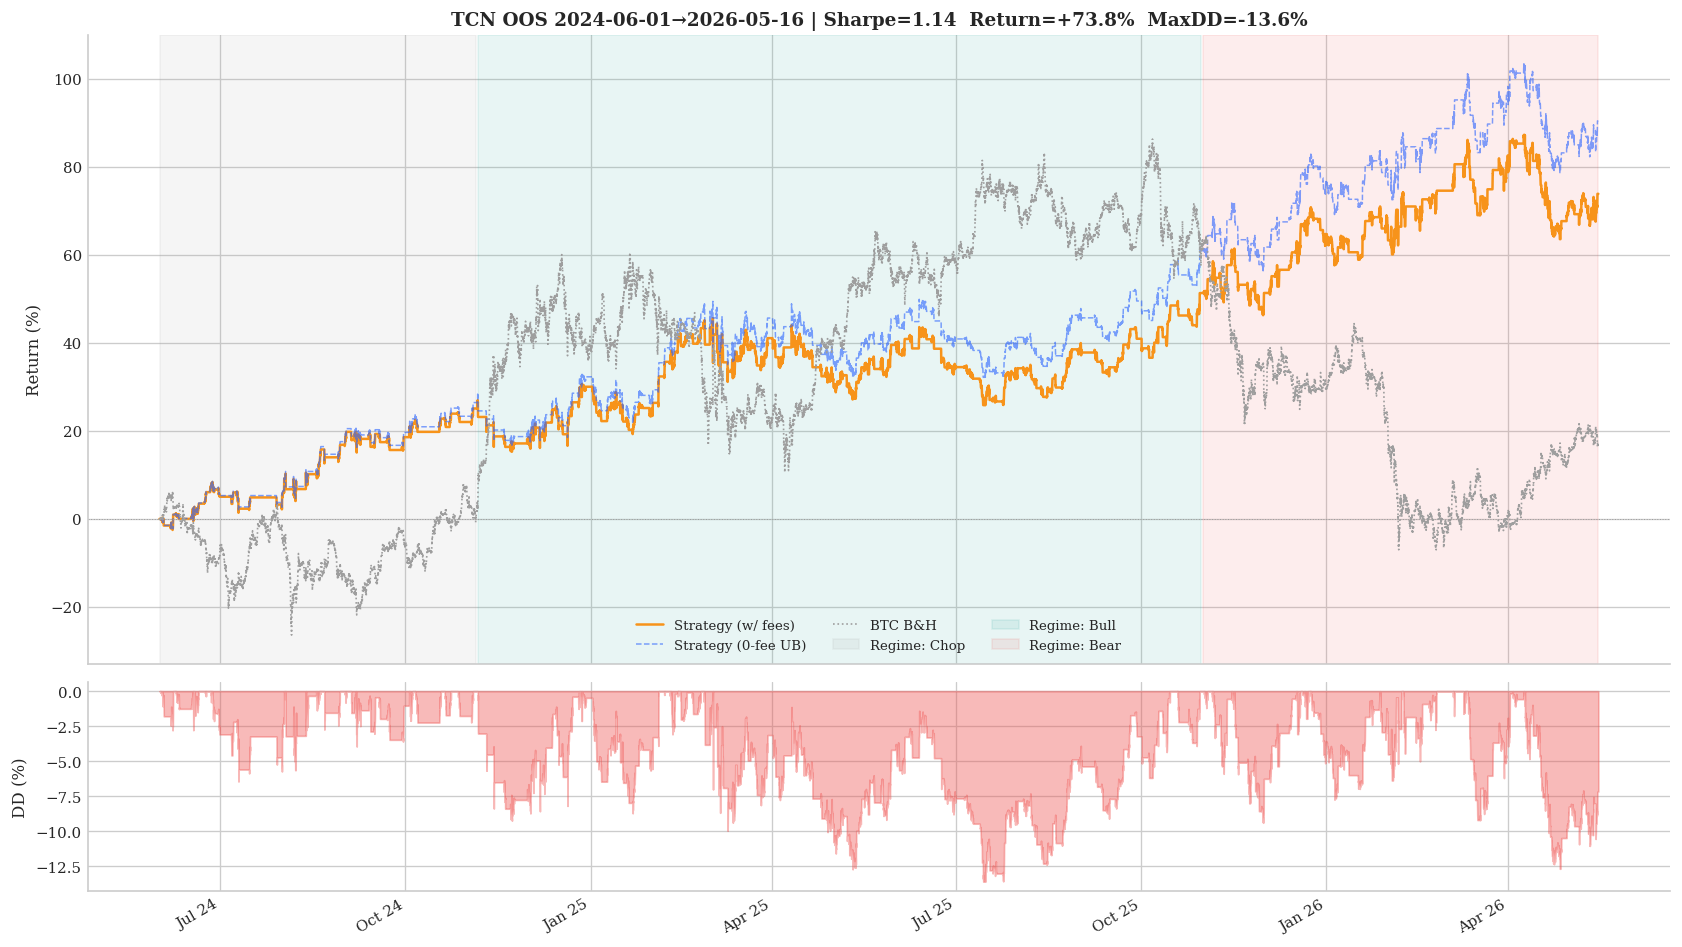

In [14]:
# Regime analysis
print('=== Regime Performance Breakdown ===')
reg_tbl = _regime_table(eq_fees, o_idx, df.loc[o_idx, 'close'].values)
print(reg_tbl.to_string())

# Shaded equity curve
fig, (ax1,ax2) = plt.subplots(2,1,figsize=(14,8),height_ratios=[3,1],sharex=True)
ax1.plot(o_idx,(eq_fees-1)*100, color=ACCENT, lw=1.5, label='Strategy (w/ fees)')
ax1.plot(o_idx,(eq_0fee-1)*100, color=BLUE,   lw=0.9, ls='--', alpha=0.6, label='Strategy (0-fee UB)')
ax1.plot(o_idx, bh,             color=GREY,   lw=1.0, ls=':',  label='BTC B&H')
for (rname,(rs,re),rc,ra) in [('Chop',REGIME_CHOP,'#9E9E9E',0.10),
                                ('Bull',REGIME_BULL,'#26A69A',0.10),
                                ('Bear',REGIME_BEAR,'#EF5350',0.10)]:
    ax1.axvspan(rs, min(re,o_idx[-1]), alpha=ra, color=rc, label=f'Regime: {rname}')
ax1.axhline(0,color=GREY,lw=0.6,ls=':'); ax1.set_ylabel('Return (%)'); ax1.legend(fontsize=8, ncol=3)
ax1.set_title(
    f'TCN OOS {OOS_START.date()}→{o_idx[-1].date()} | '
    f'Sharpe={_sharpe(eq_fees):.2f}  Return={eq_fees[-1]-1:+.1%}  MaxDD={_maxdd(eq_fees):.1%}',
    fontweight='bold')
pk=np.maximum.accumulate(eq_fees); dd=(eq_fees-pk)/pk*100
ax2.fill_between(o_idx,dd,0,color=RED,alpha=0.4); ax2.set_ylabel('DD (%)')
ax2.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1,4,7,10]))
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %y'))
plt.setp(ax2.xaxis.get_majorticklabels(),rotation=30,ha='right')
fig.tight_layout(); fig.savefig(ARTS_DIR/'01_equity_regime.png'); plt.show()